# 1. Data Loading and Inspection

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV


In [3]:
df=pd.read_csv('F:\masai_notes\Assignmnt_4a_4b_ML\data\q1_heart_disease.csv')
df.shape

(800, 12)

In [4]:
df.dtypes

age                  int64
sex                  int64
chest_pain_type        str
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg            str
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope               str
heart_disease        int64
dtype: object

In [5]:
df.isna().sum()

age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64

In [6]:
df.head()

,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


# 2. Exploratory Data Analysis

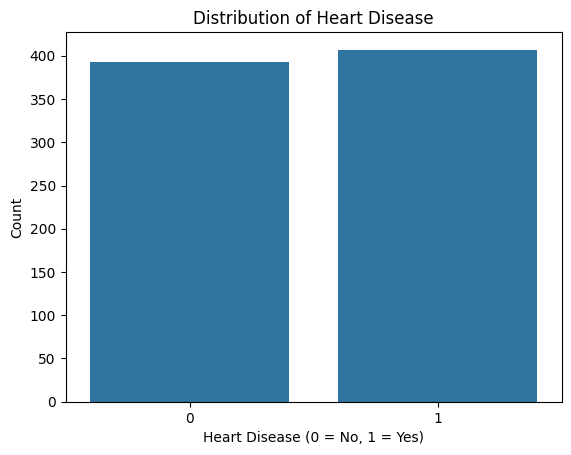

In [7]:
sns.countplot(x='heart_disease',data=df)
plt.title('Distribution of Heart Disease')
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

#### The plot shows the distribution of the target variable (heart_disease). The number of patients with heart disease (1) is slightly higher than those without heart disease (0). The dataset appears to be fairly balanced, meaning both classes have approximataly a similar number of observations.

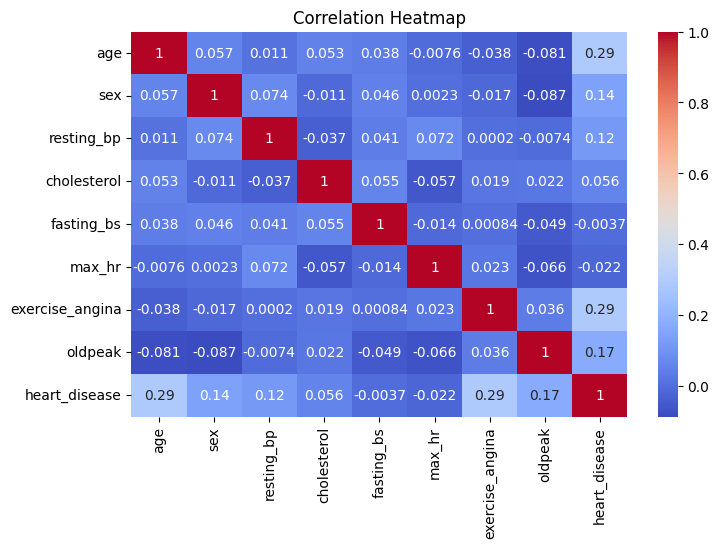

In [8]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numeric_cols].corr()
plt.figure(figsize=(8,5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

### The correlation heatmap shows the relationships between different numerical variables in the dataset. Most features have weak correlations with the target variable (heart_disease). However, age and exercise_angina show the highest positive correlation, indicating that older individuals and those experiencing exercise-induced angina are more likely to have heart disease. Other variables such as cholesterol and fasting blood sugar show very weak correlation. Overall, no feature has a very strong correlation with heart disease.

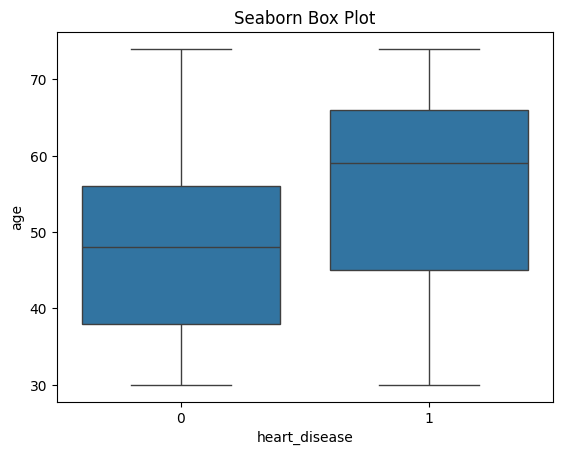

In [9]:
sns.boxplot(data=df, x='heart_disease', y='age')
plt.title('Seaborn Box Plot')
plt.show()

### The boxplot shows that people with heart disease are generally older (around 45–65 years) compared to those without it (around 38–55 years). The median age is also higher for the heart disease group. This suggests that age is an important factor in heart disease.

# 3. Data Preprocessing

In [10]:
#Handle missing values


median_resting_bp = df['resting_bp'].median()
df['resting_bp'] = df['resting_bp'].fillna(median_resting_bp)
median_cholesterol = df['cholesterol'].median()
df['cholesterol'] = df['cholesterol'].fillna(median_cholesterol)

### The dataset has 24 missing values in resting_bp and 32 in cholesterol out of 800 rows (around 4–5%). Since this is a significant amount, the missing values were filled using the median of each column to avoid losing data.

### Apply one-Hot Encoding

In [ ]:
# Apply one-hot encoding

categorical_cols = df.select_dtypes(include=['object']).columns  #--->checks for categorical columns
print(categorical_cols)                                         

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)   #---->one-hot encoding
print(df_encoded.head())                                                     #---------> ckecking the first few rows of the encoded dataframe
print(df_encoded.shape)                                                      #---------> checking the shape of the encoded dataframe

Index(['chest_pain_type', 'resting_ecg', 'st_slope'], dtype='str')
   age  sex  resting_bp  cholesterol  fasting_bs  max_hr  exercise_angina  \
0   68    0       142.0        399.0           0     169                0   
1   58    1       163.0        310.0           1     121                1   
2   44    1       128.0        175.0           0     183                1   
3   72    1       114.0        177.0           0     150                0   
4   37    1       149.0        271.0           0     136                0   

   oldpeak  heart_disease  chest_pain_type_atypical_angina  \
0      0.4              1                             True   
1      1.1              1                            False   
2      0.2              0                            False   
3      1.0              1                            False   
4      0.4              0                            False   

   chest_pain_type_non_anginal  chest_pain_type_typical_angina  \
0                        False 

C:\Users\gptak\AppData\Local\Temp\ipykernel_23220\2362338338.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns  #--->checks for categorical columns


### Scaling Numerical Feature using Standard Scaler

In [16]:

X = df_encoded.drop('heart_disease', axis=1)  #---> dropping the target variable from the features
y = df_encoded['heart_disease']             #---> target variable

numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns   #---> selecting only numerical columns for scaling

scaler = StandardScaler()                                               #---> applying standard scaler to the numerical columns
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])             #---> fitting and transforming the numerical columns with the scaler

print(X.head())                                                               #---> checking the first few rows of the scaled features

        age       sex  resting_bp  cholesterol  fasting_bs    max_hr  \
0  1.229854 -1.408927    0.702830     3.000527   -0.550392  0.887081   
1  0.451896  0.709760    2.003076     1.258794    1.816886 -1.257462   
2 -0.637245  0.709760   -0.164001    -1.383161   -0.550392  1.512573   
3  1.541037  0.709760   -1.030832    -1.344021   -0.550392  0.038200   
4 -1.181815  0.709760    1.136245     0.495562   -0.550392 -0.587292   

   exercise_angina   oldpeak  chest_pain_type_atypical_angina  \
0        -0.646869 -0.585809                             True   
1         1.545908  0.194526                            False   
2         1.545908 -0.808762                            False   
3        -0.646869  0.083050                            False   
4        -0.646869 -0.585809                            False   

   chest_pain_type_non_anginal  chest_pain_type_typical_angina  \
0                        False                           False   
1                         True              

### Train_Test_Split


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 4. Model Training 

In [20]:


# Initialize models
dt_model = DecisionTreeClassifier(random_state=42)
rf_model = RandomForestClassifier(random_state=42)
gb_model = GradientBoostingClassifier(random_state=42)

# Train models
dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

# 5. Model Evaluation

In [22]:
# Decision Tree predictions
y_pred_dt = dt_model.predict(X_test)

# Random Forest predictions
y_pred_rf = rf_model.predict(X_test)

# Gradient Boosting predictions
y_pred_gb = gb_model.predict(X_test)




### Confusion Metric



In [ ]:
print("Decision Tree Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("\nRandom Forest Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nGradient Boosting Confusion Matrix:\n", confusion_matrix(y_test, y_pred_gb))

Decision Tree Confusion Matrix:
 [[56 23]
 [25 56]]

Random Forest Confusion Matrix:
 [[61 18]
 [15 66]]

Gradient Boosting Confusion Matrix:
 [[61 18]
 [19 62]]


### Precision, Recall, and F1-score

In [24]:
print("\nDecision Tree Classification Report:\n")
print(classification_report(y_test, y_pred_dt))

print("\nRandom Forest Classification Report:\n")
print(classification_report(y_test, y_pred_rf))

print("\nGradient Boosting Classification Report:\n")
print(classification_report(y_test, y_pred_gb))


Decision Tree Classification Report:

              precision    recall  f1-score   support

           0       0.69      0.71      0.70        79
           1       0.71      0.69      0.70        81

    accuracy                           0.70       160
   macro avg       0.70      0.70      0.70       160
weighted avg       0.70      0.70      0.70       160


Random Forest Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.77      0.79        79
           1       0.79      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160


Gradient Boosting Classification Report:

              precision    recall  f1-score   support

           0       0.76      0.77      0.77        79
           1       0.78      0.77      0.77        81

    accuracy                           0.77       160
   macr

# Model Comparison and Conclusion
The Decision Tree model gives average results with 70% accuracy. It works okay but is not as strong as the other models.
The Random Forest model gives the best results with 79% accuracy and the highest F1-score. It also has the highest recall (0.81) for heart disease cases, which means it can detect more patients correctly.
The Gradient Boosting model also performs well with 77% accuracy, but it is slightly worse than Random Forest.

## Conclusion:
The Random Forest model is the best because it has the highest accuracy, F1-score, and recall. It is especially good at detecting heart disease cases, which is very important.

# 6. Hyperparameter Tuning

In [29]:
param_grid = {'n_estimators': [100, 200, 300], 'max_depth': [None, 5, 10, 20], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4], 'bootstrap': [True, False]}
grid_search = GridSearchCV( estimator=rf_model, param_grid=param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'bootstrap': True, 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300}


In [30]:
best_model = grid_search.best_estimator_

y_pred_best = best_model.predict(X_test)

print("Tuned Model Performance:\n")
print(classification_report(y_test, y_pred_best))

Tuned Model Performance:

              precision    recall  f1-score   support

           0       0.77      0.72      0.75        79
           1       0.74      0.79      0.77        81

    accuracy                           0.76       160
   macro avg       0.76      0.76      0.76       160
weighted avg       0.76      0.76      0.76       160



### Hyperparameter Tuning Result

GridSearchCV was used to tune the Random Forest model. The tuned model gave 76% accuracy, which is lower than the original model (79%). The F1-score was also lower than the original model.



### Conclusion

The tuned model did not improve the performance. So, the original Random Forest model is still the best model for this dataset. This shows that hyperparameter tuning does not always improve results.